# Strand A (temporal), user level: does the measurement date move exposure?

**Estimand at risk:** user-level exposure during June-2022 browsing.
**Threat (T1):** per-domain tracking measured ~Jan 2025, not June 2022.
**Contribution of this notebook:** the user-level version of the temporal
bound. Exposure is computed twice from the *same* instrument (HTTP Archive) —
once with per-domain tracking measured in June 2022 (the browsing window) and
once with tracking measured in January 2025 (the Blacklight scan window) —
over the same matched domain set. Because instrument and construction are
identical at both ends, any difference is change over time, not instrument
scale.

Construction mirrors `02_combine_yg_blacklight.ipynb`: a user's exposure rate
is the visit-weighted sum of per-domain tracker counts divided by total
visits; domains without a measurement contribute zero (as in the paper).

A validation cell first confirms this notebook's construction reproduces the
paper's published Blacklight-based rates exactly.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

import config
from utilities import pandas_to_tex, save_mpl_fig

MEASURES4 = [
    ("ddg_join_ads", "Ad trackers"),
    ("third_party_cookies", "Third-party cookies (header-set)"),
    ("fb_pixel", "Facebook requests"),
    ("google_analytics", "Google Analytics/GTM"),
]
KEYS = [k for k, _ in MEASURES4]

Checking that all paths exist:
{'web_mobile': False, 'web_desktop': False, 'web': False, 'yg_profile': False, 'blacklight': False, 'who': False}


In [2]:
yg = pd.read_csv(config.FP_YG_IND_DOMAIN)
yg["filename"] = yg["private_domain"].str.replace(".", "_", regex=False)

bl = pd.read_csv(config.FP_BLACKLIGHT)

ha = pd.read_csv(config.FP_HA_DOMAIN_MEASURES)
ha22 = ha.query("crawl == 'panel'").groupby("private_domain")[KEYS].mean()
ha25 = (
    ha.query("crawl == 'blacklight_match'").groupby("private_domain")[KEYS].mean()
)
matched = ha22.index.intersection(ha25.index)
print(f"user x domain rows: {len(yg):,}")
print(f"HA June-2022 domains: {len(ha22):,}")
print(f"HA Jan-2025 domains : {len(ha25):,}")
print(f"matched (both crawls): {len(matched):,}")

user x domain rows: 186,400
HA June-2022 domains: 13,583
HA Jan-2025 domains : 12,776
matched (both crawls): 12,056


## What share of browsing do the sources cover?

In [3]:
tot = yg["visits"].sum()
on_bl = yg["filename"].isin(set(bl["filename"]))
on_22 = yg["private_domain"].isin(set(ha22.index))
on_m = yg["private_domain"].isin(set(matched))
coverage = pd.Series({
    "visits on Blacklight-scanned domains (%)": 100 * yg.loc[on_bl, "visits"].sum() / tot,
    "visits on HA June-2022 domains (%)": 100 * yg.loc[on_22, "visits"].sum() / tot,
    "visits on HA matched 2022+2025 domains (%)": 100 * yg.loc[on_m, "visits"].sum() / tot,
    "visits on Blacklight or HA-2022 (%)": 100 * yg.loc[on_bl | on_22, "visits"].sum() / tot,
}).round(1)
coverage

visits on Blacklight-scanned domains (%)      76.4
visits on HA June-2022 domains (%)            81.3
visits on HA matched 2022+2025 domains (%)    78.9
visits on Blacklight or HA-2022 (%)           91.2
dtype: float64

## Validation: the construction reproduces the paper's rates

Recomputing user-level rates from `yg_ind_domain` x `blacklight_domain` must
match the published per-user rates in the combined analysis file.

In [4]:
merged_bl = yg.merge(
    bl.rename(columns={k: f"bl_{k}" for k in bl.columns if k != "filename"}),
    on="filename", how="left",
)
tt_visits = merged_bl.groupby("caseid")["visits"].sum()

BL_KEYS = ["ddg_join_ads", "third_party_cookies", "fb_pixel", "google_analytics"]
rates_bl = pd.DataFrame({
    k: (merged_bl[f"bl_{k}"].fillna(0) * merged_bl["visits"])
    .groupby(merged_bl["caseid"]).sum() / tt_visits
    for k in BL_KEYS
})

comb = pd.read_csv(
    os.path.join(config.DATA_DIR, "combined_yg_bl_who_derived_hist_tracking.csv"),
    usecols=["caseid"] + [f"bl_{k}_rate" for k in BL_KEYS],
).set_index("caseid")
sample = comb.index  # the paper's analytical sample
for k in BL_KEYS:
    r = rates_bl.reindex(sample)[k].corr(comb[f"bl_{k}_rate"])
    print(f"corr(recomputed, published) {k:22}: {r:.4f}")

corr(recomputed, published) ddg_join_ads          : 1.0000
corr(recomputed, published) third_party_cookies   : 1.0000
corr(recomputed, published) fb_pixel              : 1.0000
corr(recomputed, published) google_analytics      : 1.0000


## User-level exposure: June-2022 vs Jan-2025 measurement

Same instrument, same matched domains; only the measurement date differs.

In [5]:
dom = pd.DataFrame(index=matched)
dom = dom.join(ha22.loc[matched].add_prefix("h22_"))
dom = dom.join(ha25.loc[matched].add_prefix("h25_"))
merged = yg.merge(dom, left_on="private_domain", right_index=True, how="left")
tt = merged.groupby("caseid")["visits"].sum()


def user_rates(prefix):
    return pd.DataFrame({
        k: (merged[f"{prefix}_{k}"].fillna(0) * merged["visits"])
        .groupby(merged["caseid"]).sum() / tt
        for k in KEYS
    })


r22 = user_rates("h22").reindex(sample)
r25 = user_rates("h25").reindex(sample)

In [6]:
rows = []
for k, label in MEASURES4:
    rows.append({
        "measure": label,
        "rate_jun2022_mean": r22[k].mean(),
        "rate_jan2025_mean": r25[k].mean(),
        "mean_change_pct": 100 * (r25[k].mean() - r22[k].mean()) / r22[k].mean(),
        "corr_user_level": r22[k].corr(r25[k]),
    })
summary = pd.DataFrame(rows)
summary.round(3)

,measure,rate_jun2022_mean,rate_jan2025_mean,mean_change_pct,corr_user_level
0,Ad trackers,18.076,16.936,-6.307,0.816
1,Third-party cookies (header-set),10.168,12.427,22.217,0.744
2,Facebook requests,0.476,0.332,-30.265,0.746
3,Google Analytics/GTM,0.702,0.672,-4.302,0.907


In [7]:
tex = summary.copy()
for c in ["rate_jun2022_mean", "rate_jan2025_mean"]:
    tex[c] = tex[c].map("{:.3f}".format)
tex["mean_change_pct"] = tex["mean_change_pct"].map("{:+.1f}".format)
tex["corr_user_level"] = tex["corr_user_level"].map("{:.2f}".format)
pandas_to_tex(tex, os.path.join(config.TABLES_DIR, "temporal_user_exposure"))
print("wrote tables/temporal_user_exposure.tex")

wrote tables/temporal_user_exposure.tex


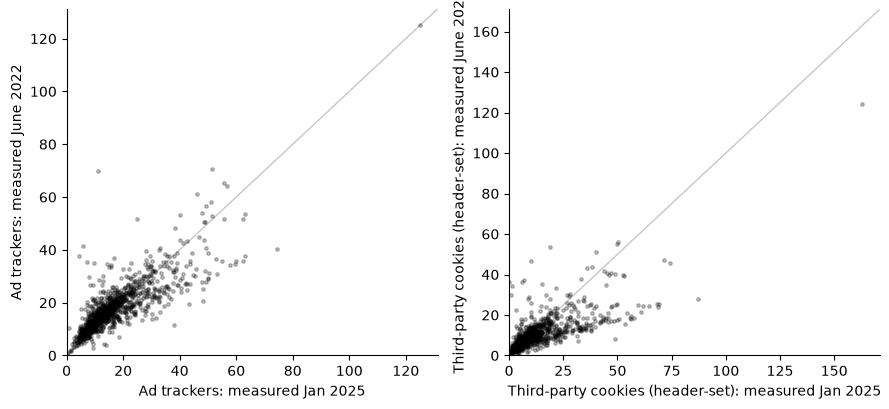

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, (k, label) in zip(axes, MEASURES4[:2]):
    a, b = r25[k], r22[k]
    lim = max(a.max(), b.max()) * 1.05
    ax.plot([0, lim], [0, lim], color="#c7c7c7", lw=1, zorder=1)
    ax.scatter(a, b, s=6, color="#000000", alpha=0.25, zorder=2)
    ax.set_xlabel(f"{label}: measured Jan 2025")
    ax.set_ylabel(f"{label}: measured June 2022")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_mpl_fig(os.path.join(config.FIGURES_DIR, "temporal_user_exposure"))
plt.show()

## Reading the results

`mean_change_pct` is the signed user-level answer to the temporal question:
how much higher or lower average exposure looks when tracking is measured in
Jan 2025 rather than during the June-2022 browsing window, holding the
instrument and domain set fixed. A negative value means 2025-era measurement
*understates* 2022 exposure. `corr_user_level` says whether the cross-user
ordering — which the demographic analyses depend on — is preserved across
measurement dates.